# Diseño de Sistemas de Producción - Escenario 03
Este cuaderno consolida el análisis de productividad y la optimización logística del **Escenario 03**.
Se divide en las siguientes fases paso a paso, incluyendo tablas y gráficos ilustrativos.


In [41]:
import pandas as pd
import numpy as np
from scipy.optimize import linprog
from math import radians, cos, sin, asin, sqrt
import os
import matplotlib.pyplot as plt
import seaborn as sns

data_dir = r"data\Escenario_03"
warmup_days = 60
warmup_hours = warmup_days * 24


## 1. Caracterización de Flujos
Filtramos los datos excluyendo el período de calentamiento (60 días) y calculamos los promedios de entrada de materia prima y salida de productos terminados por réplica.


In [42]:
# Carga de datos
calendar_df = pd.read_csv(os.path.join(data_dir, "calendar.csv"))
eval_hours = (calendar_df['day'].max() * 24 + 24) - warmup_hours

log_arrivals = pd.read_csv(os.path.join(data_dir, "log_arrivals.csv"))
log_arrivals_valid = log_arrivals[log_arrivals['arrival_time_h'] > warmup_hours]
total_in = log_arrivals_valid['volume_m3'].sum()

product_outputs = pd.read_csv(os.path.join(data_dir, "product_outputs.csv"))
product_outputs_valid = product_outputs[product_outputs['exit_time_h'] > warmup_hours]
total_out = product_outputs_valid['volume_m3'].sum()

num_replications = product_outputs['replication'].nunique()

promedio_entrada = total_in / num_replications
promedio_salida = total_out / num_replications
promedio_por_producto = (product_outputs_valid.groupby('product')['volume_m3'].sum() / num_replications).reset_index()

# Mostrar Resultados en Tabla
df_flujos = pd.DataFrame({
    'Métrica': ['Total Trozos (Input)', 'Total Prod. Terminados (Output)'],
    'Volumen (m3)': [promedio_entrada, promedio_salida],
    'Tasa (m3/hora)': [promedio_entrada / eval_hours, promedio_salida / eval_hours]
})
display(df_flujos.style.format({'Volumen (m3)': '{:,.2f}', 'Tasa (m3/hora)': '{:,.2f}'}))

# Mostrar producción por producto
promedio_por_producto['Tasa (m3/hora)'] = promedio_por_producto['volume_m3'] / eval_hours
df_prod = promedio_por_producto.rename(columns={'product': 'Producto', 'volume_m3': 'Volumen (m3)'})
display(df_prod.style.format({'Volumen (m3)': '{:,.2f}', 'Tasa (m3/hora)': '{:,.2f}'}).background_gradient(cmap='Greens'))


,Métrica,Volumen (m3),Tasa (m3/hora)
0,Total Trozos (Input),"55,235.55",7.55
1,Total Prod. Terminados (Output),"24,970.93",3.41


,Producto,Volumen (m3),Tasa (m3/hora)
0,P1,"8,463.70",1.16
1,P2,"10,788.81",1.47
2,P3,"5,718.41",0.78


## 2. Métricas de Desempeño (KPIs) por Estación
Analizamos el estado de las máquinas para calcular su **Utilización** y **Disponibilidad**. Aquí identificaremos claramente nuestro cuello de botella.


state,station,Utilization,Availability
0,aserradero,55.04%,98.95%
1,bano,8.17%,99.95%
2,drymill,32.78%,99.49%
3,impregnado,7.93%,99.88%
4,secado,93.05%,93.52%


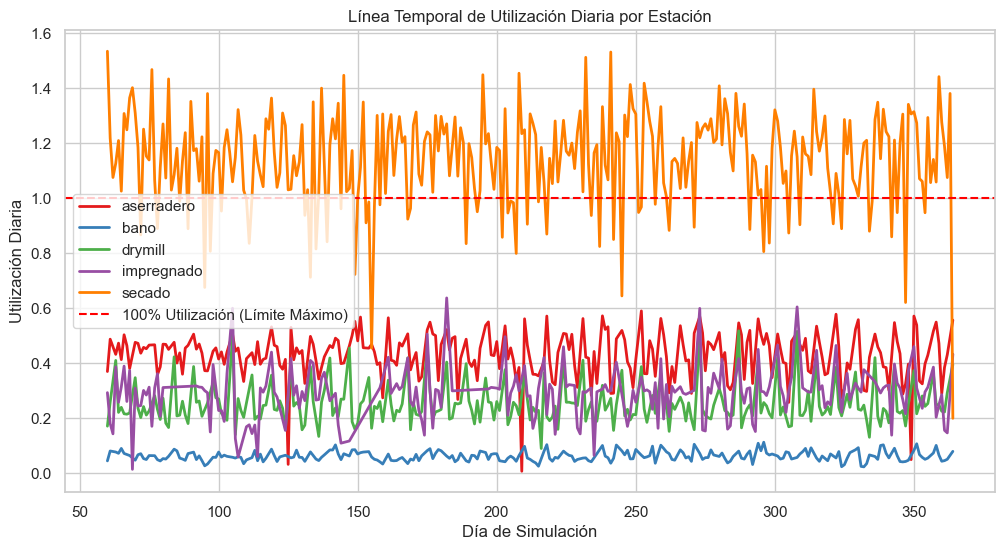

In [43]:
station_events = pd.read_csv(os.path.join(data_dir, "station_events.csv"))
se_valid = station_events[station_events['end_time_h'] > warmup_hours].copy()
se_valid['start_time_h'] = np.maximum(se_valid['start_time_h'], warmup_hours)
se_valid['duration'] = se_valid['end_time_h'] - se_valid['start_time_h']

state_durations = se_valid.groupby(['replication', 'station', 'state'])['duration'].sum().reset_index()

pivot_states = state_durations.pivot_table(index=['replication', 'station'], columns='state', values='duration', fill_value=0).reset_index()

if 'OFF_SHIFT' in pivot_states.columns:
    pivot_states['Operating_Time'] = eval_hours - pivot_states['OFF_SHIFT']
else:
    pivot_states['Operating_Time'] = eval_hours

if 'DOWN' not in pivot_states.columns: pivot_states['DOWN'] = 0
if 'BUSY' not in pivot_states.columns: pivot_states['BUSY'] = 0

pivot_states['Utilization'] = pivot_states['BUSY'] / pivot_states['Operating_Time']
pivot_states['Availability'] = (pivot_states['Operating_Time'] - pivot_states['DOWN']) / pivot_states['Operating_Time']

mean_kpis = pivot_states.groupby('station')[['Utilization', 'Availability']].mean().reset_index()

display(mean_kpis.style.format({'Utilization': '{:.2%}', 'Availability': '{:.2%}'}).background_gradient(cmap='Reds', subset=['Utilization']))

# Calcular utilización diaria (línea temporal)
se_valid['day'] = (se_valid['start_time_h'] // 24).astype(int)
# Sumar duraciones BUSY por día, réplica y estación
daily_busy = se_valid[se_valid['state'] == 'BUSY'].groupby(['replication', 'station', 'day'])['duration'].sum().reset_index()
# Suponiendo 24 horas por día operativo (simplificación para la tendencia)
daily_busy['Daily_Utilization'] = daily_busy['duration'] / 24

# Gráfico de Línea Temporal
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_busy, x='day', y='Daily_Utilization', hue='station', errorbar=None, linewidth=2, palette='Set1')
plt.title('Línea Temporal de Utilización Diaria por Estación')
plt.xlabel('Día de Simulación')
plt.ylabel('Utilización Diaria')
plt.axhline(1.0, color='red', linestyle='--', label='100% Utilización (Límite Máximo)')
plt.legend()
plt.show()


## 3. Tiempos de Ciclo Promedio
Calculamos cuánto tiempo le toma a cada máquina procesar un lote desde que entra hasta que sale. Esto refuerza la identificación del cuello de botella.


In [44]:
batches = pd.read_csv(os.path.join(data_dir, "batches.csv"))
batches_valid = batches[batches['start_process_time_h'] > warmup_hours].copy()

batches_valid['cycle_time'] = batches_valid['end_process_time_h'] - batches_valid['start_process_time_h']
mean_cycle_time = batches_valid.groupby('station')['cycle_time'].mean().reset_index()
mean_cycle_time.rename(columns={'station': 'Estación', 'cycle_time': 'Tiempo de Ciclo (Horas)'}, inplace=True)

display(mean_cycle_time.style.format({'Tiempo de Ciclo (Horas)': '{:.2f}'}).background_gradient(cmap='Purples'))


,Estación,Tiempo de Ciclo (Horas)
0,aserradero,1.45
1,bano,0.57
2,drymill,2.96
3,impregnado,3.56
4,secado,27.79


## 4. Análisis de Inventarios (WIP) y Cuello de Botella
Vamos a observar cómo se acumula el material antes de cada estación. Un nivel de inventario masivo antes de una máquina es el indicador definitivo de un cuello de botella.


In [45]:
daily_wip = pd.read_csv(os.path.join(data_dir, "daily_wip.csv"))
daily_wip_valid = daily_wip[daily_wip['day'] > warmup_days]

buffer_stats = daily_wip_valid.groupby('buffer').agg(
    WIP_Promedio=('level_m3_mean', 'mean'),
    WIP_Maximo=('level_m3_max', 'max')
).reset_index()

display(buffer_stats.style.format({'WIP_Promedio': '{:.2f}', 'WIP_Maximo': '{:.2f}'}).background_gradient(cmap='Oranges'))


,buffer,WIP_Promedio,WIP_Maximo
0,log_yard,655.07,2830.13
1,stock_aserrado,427.92,535.00
2,stock_drymill,2.77,65.89
3,stock_seco,16.92,155.20


## 5. Optimización Logística (Problema de Transporte)
Formulamos la red de distribución como un **Problema de Transporte** (un caso de Flujo de Costo Mínimo o MCNF). 
Asignaremos el flujo óptimo desde el nodo de oferta (Aserradero Mulchén) hacia los nodos de demanda (puertos y plantas), minimizando los costos de los arcos. 
La métrica de distancia de red se obtiene de forma real vía OSRM (con Haversine como respaldo).


In [46]:
import requests

def get_driving_distance(lat1, lon1, lat2, lon2):
    # Uso de la API pública de OSRM (Open Source Routing Machine) para calcular distancia REAL por carretera
    try:
        url = f"http://router.project-osrm.org/route/v1/driving/{lon1},{lat1};{lon2},{lat2}?overview=false"
        r = requests.get(url)
        if r.status_code == 200:
            return r.json()['routes'][0]['distance'] / 1000.0 # m a km
    except:
        pass
    
    # Fallback: Fórmula de Haversine * Factor de Ruteo 1.3
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    a = sin((lat2-lat1)/2)**2 + cos(lat1) * cos(lat2) * sin((lon2-lon1)/2)**2
    return 2 * asin(sqrt(a)) * 6371 * 1.3

nodes = {
    'Mulchen': (-37.7165, -72.2412),
    'P_Coronel': (-37.0298, -73.1432),
    'P_San_Vicente': (-36.7214, -73.1311),
    'P_Lirquen': (-36.7095, -72.9764),
    'R_Coronel': (-37.0253, -73.1345),
    'R_Los_Angeles': (-37.2618, -72.6975),
    'Ply_Collipulli': (-37.9547, -72.4190)
}
dests = ['P_Coronel', 'P_San_Vicente', 'P_Lirquen', 'R_Coronel', 'R_Los_Angeles', 'Ply_Collipulli']

print("Calculando distancias reales por carretera (vía OSRM API)...")
distances = {}
for d in dests:
    distances[d] = get_driving_distance(nodes['Mulchen'][0], nodes['Mulchen'][1], nodes[d][0], nodes[d][1])
    print(f" - Mulchén a {d}: {distances[d]:.1f} km")

products = ['P1', 'P2', 'P3']
prod_dict = promedio_por_producto.set_index('product')['volume_m3'].to_dict()

bounds_dict = {
    'P1': {'P_Coronel': (1200, 12000), 'R_Coronel': (1500, 8000), 'R_Los_Angeles': (1300, 6000)},
    'P2': {'P_Lirquen': (1500, 8000), 'P_San_Vicente': (1500, 8000), 'R_Los_Angeles': (1500, 5000), 'Ply_Collipulli': (1500, 5000)},
    'P3': {'P_Coronel': (1200, 10000), 'P_San_Vicente': (800, 12000), 'Ply_Collipulli': (1000, 4000)}
}

variables, bounds, cost_coefficients = [], [], []

for p in products:
    for d in dests:
        variables.append((p, d))
        cost_coefficients.append(distances[d] * 100) 
        bounds.append(bounds_dict[p].get(d, (0, 0)))

A_eq, b_eq = np.zeros((3, 18)), np.zeros(3)
for i, p in enumerate(products):
    b_eq[i] = prod_dict[p]
    for j, var in enumerate(variables):
        if var[0] == p: A_eq[i, j] = 1

res = linprog(cost_coefficients, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

if res.success:
    resultados = []
    for j, var in enumerate(variables):
        if res.x[j] > 0.01:
            resultados.append({
                'Producto': var[0], 'Destino': var[1], 'Volumen (m3)': res.x[j],
                'Distancia (km)': distances[var[1]], 'Costo (CLP)': res.x[j] * 100 * distances[var[1]]
            })
    df_opt = pd.DataFrame(resultados)
    
    print(f"COSTO LOGÍSTICO TOTAL MÍNIMO: $ {res.fun:,.0f} CLP")
    display(df_opt.style.format({'Volumen (m3)': '{:,.2f}', 'Distancia (km)': '{:.1f}', 'Costo (CLP)': '$ {:,.0f}'}))
else:
    print("Error:", res.message)


Calculando distancias reales por carretera (vía OSRM API)...
 - Mulchén a P_Coronel: 145.7 km
 - Mulchén a P_San_Vicente: 174.9 km
 - Mulchén a P_Lirquen: 172.6 km
 - Mulchén a R_Coronel: 144.5 km
 - Mulchén a R_Los_Angeles: 76.4 km
 - Mulchén a Ply_Collipulli: 38.9 km
COSTO LOGÍSTICO TOTAL MÍNIMO: $ 222,015,438 CLP


,Producto,Destino,Volumen (m3),Distancia (km),Costo (CLP)
0,P1,P_Coronel,"1,200.00",145.7,"$ 17,483,592"
1,P1,R_Coronel,"1,500.00",144.5,"$ 21,672,285"
2,P1,R_Los_Angeles,"5,763.70",76.4,"$ 44,048,956"
3,P2,P_San_Vicente,"1,500.00",174.9,"$ 26,227,665"
4,P2,P_Lirquen,"1,500.00",172.6,"$ 25,889,355"
5,P2,R_Los_Angeles,"2,788.81",76.4,"$ 21,313,461"
6,P2,Ply_Collipulli,"5,000.00",38.9,"$ 19,446,450"
7,P3,P_Coronel,"1,200.00",145.7,"$ 17,483,592"
8,P3,P_San_Vicente,800.00,174.9,"$ 13,988,088"
9,P3,Ply_Collipulli,"3,718.41",38.9,"$ 14,461,994"
